# CIFAR-10 彩色图片卷积神经网络完整案例

这个 Notebook 使用 **卷积神经网络** 识别 CIFAR-10 彩色图片。

CIFAR-10 比 Fashion-MNIST 更接近真实世界图像：

- 图片是彩色图，不是灰度图
- 每张图片大小是 32×32
- 每张图片有 RGB 三个颜色通道
- 类别包括飞机、汽车、鸟、猫、狗、船、卡车等

本案例会依次完成：

1. 加载 CIFAR-10 数据集
2. 观察彩色图片和标签
3. 理解 RGB 三通道
4. 数据归一化
5. 拆分训练集和验证集
6. 构建带数据增强的 CNN 模型
7. 训练模型
8. 绘制训练曲线
9. 测试集评估
10. 单张预测和批量预测
11. 混淆矩阵和错误案例分析
12. 保存并重新加载模型

---

## 为什么 CIFAR-10 更有挑战

Fashion-MNIST 图片比较规整，背景简单，只有灰度。  
CIFAR-10 是真实小图片，背景更复杂，颜色更多，物体姿态也更多变。

因此，CIFAR-10 更适合用来展示 CNN 在真实图像分类中的作用。

# 第 0 步：环境准备

如果还没有安装相关库，可以先在终端中运行：

```bash
python -m pip install tensorflow matplotlib numpy
```

如果在 Notebook 中运行，也可以新建一个代码单元格执行：

```python
!python -m pip install tensorflow matplotlib numpy
```

本案例主要使用：

- `tensorflow`：构建和训练神经网络
- `keras`：TensorFlow 中的高级神经网络接口
- `numpy`：处理数组和数值计算
- `matplotlib`：展示图片和绘制图表

In [1]:
# ============================================================
# 第 0 步：环境准备与库导入
# ============================================================

import os

# ------------------------------------------------------------
# 必须在导入 tensorflow / keras 之前设置。
# 如果本机 Keras 默认后端不是 TensorFlow，这一行可以确保本案例使用 TensorFlow。
# ------------------------------------------------------------
os.environ["KERAS_BACKEND"] = "tensorflow"

# 减少不影响学习的 TensorFlow 提示信息。
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"

import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow 版本：", tf.__version__)
print("Keras 版本：", keras.__version__)
print("当前 Keras 后端：tensorflow")

ModuleNotFoundError: No module named 'tensorflow'

# 第 0.1 步：设置中文字体

如果图表中的中文显示为方框，通常是因为 Matplotlib 没有找到中文字体。

下面会按顺序尝试常见中文字体：

- macOS：`PingFang SC`、`Heiti SC`、`Arial Unicode MS`
- Windows：`Microsoft YaHei`、`SimHei`
- Linux：`Noto Sans CJK SC`、`WenQuanYi Zen Hei`

In [2]:
# ============================================================
# 第 0.1 步：设置 Matplotlib 中文字体
# ============================================================

def set_chinese_font():
    """
    设置 Matplotlib 中文字体。

    说明：
    1. Matplotlib 会按顺序寻找字体。
    2. 找到第一个系统中存在的字体后，就会使用它。
    3. 如果所有字体都不存在，中文可能仍然显示为方框。
    """
    plt.rcParams["font.sans-serif"] = [
        "PingFang SC",
        "Heiti SC",
        "Arial Unicode MS",
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "WenQuanYi Zen Hei",
        "DejaVu Sans",
    ]
    plt.rcParams["axes.unicode_minus"] = False

set_chinese_font()
print("中文字体设置完成。")

中文字体设置完成。


# 第 0.2 步：固定随机种子

神经网络训练中有很多随机因素，例如：

- 参数初始化
- 数据打乱
- Dropout 随机丢弃神经元
- 随机抽取图片展示

固定随机种子后，每次运行结果会尽量接近，方便对照观察。

In [3]:
# ============================================================
# 第 0.2 步：固定随机种子
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("随机种子已固定：", SEED)

随机种子已固定： 42


# 第 0.3 步：自动检测硬件加速

TensorFlow 会自动使用它能识别到的加速设备。

常见情况包括：

- Windows / Linux 上的 NVIDIA GPU：需要 TensorFlow 环境能识别 CUDA GPU
- Windows 电脑：较新的 TensorFlow GPU 环境通常通过 WSL2 使用 NVIDIA GPU
- macOS Apple Silicon：需要安装支持 Metal 的 TensorFlow 插件后，TensorFlow 才能看到 Mac GPU
- 没有可用 GPU：自动使用 CPU，代码仍然可以正常运行

下面的代码会：

1. 检测当前操作系统和处理器架构。
2. 检测 TensorFlow 能看到哪些 GPU。
3. 如果检测到 GPU，就让 TensorFlow 尽量按需申请显存。
4. 如果检测到 GPU，就尝试开启混合精度训练。

混合精度训练会同时使用 16 位和 32 位浮点数。  
在合适的 GPU 上，它通常可以减少显存占用并提高训练速度。

In [4]:
# ============================================================
# 第 0.3 步：自动检测硬件加速
# ============================================================

import platform

print("操作系统：", platform.system())
print("处理器架构：", platform.machine())

physical_gpus = tf.config.list_physical_devices("GPU")

if physical_gpus:
    print("检测到可用 GPU 数量：", len(physical_gpus))

    for gpu in physical_gpus:
        print("GPU 设备：", gpu)

    # ------------------------------------------------------------
    # 按需申请显存：
    # 有些 GPU 后端支持这个设置，有些后端不支持。
    # 如果不支持，跳过即可，不影响后续训练。
    # ------------------------------------------------------------
    for gpu in physical_gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            print("已启用显存按需增长：", gpu.name)
        except Exception as error:
            print("显存按需增长设置跳过：", gpu.name, "原因：", error)

    # ------------------------------------------------------------
    # 混合精度训练：
    # 在支持半精度计算的 GPU 上，可能提升训练速度并减少显存占用。
    # 如果当前环境不支持，跳过即可。
    # ------------------------------------------------------------
    try:
        from tensorflow.keras import mixed_precision

        mixed_precision.set_global_policy("mixed_float16")
        print("已尝试启用混合精度训练：mixed_float16")
        print("当前全局计算精度策略：", mixed_precision.global_policy())
    except Exception as error:
        print("混合精度训练未启用，原因：", error)
else:
    print("未检测到 TensorFlow 可用的 GPU，当前将使用 CPU 训练。")

    if platform.system() == "Darwin" and platform.machine() in ["arm64", "aarch64"]:
        print("当前是 Apple Silicon Mac。如果安装了 tensorflow-metal，TensorFlow 可能可以使用 Mac GPU。")
    elif platform.system() == "Windows":
        print("当前是 Windows。如果需要 NVIDIA GPU 加速，通常需要配置 WSL2 和对应的 CUDA 环境。")

操作系统： Darwin
处理器架构： arm64
检测到可用 GPU 数量： 1
GPU 设备： PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
已启用显存按需增长： /physical_device:GPU:0
已尝试启用混合精度训练：mixed_float16
当前全局计算精度策略： <DTypePolicy "mixed_float16">


# 第 1 步：加载 CIFAR-10 数据集

CIFAR-10 是一个经典彩色图片分类数据集。

它包含：

- 50,000 张训练图片
- 10,000 张测试图片
- 每张图片大小为 32×32
- 每张图片有 3 个颜色通道：红色、绿色、蓝色
- 每张图片属于 10 个类别之一

| 标签编号 | 英文类别 | 中文含义 |
|---|---|---|
| 0 | airplane | 飞机 |
| 1 | automobile | 汽车 |
| 2 | bird | 鸟 |
| 3 | cat | 猫 |
| 4 | deer | 鹿 |
| 5 | dog | 狗 |
| 6 | frog | 青蛙 |
| 7 | horse | 马 |
| 8 | ship | 船 |
| 9 | truck | 卡车 |

In [5]:
# ============================================================
# 第 1 步：加载 CIFAR-10 数据集
# ============================================================

from pathlib import Path
import tarfile
import pickle


def load_cifar10_from_local_archive(archive_path):
    """
    从本地 CIFAR-10 Python 版压缩包中读取数据。

    说明：
    1. CIFAR-10 Python 版压缩包名通常是 cifar-10-python.tar.gz。
    2. 解压后会得到 cifar-10-batches-py 文件夹。
    3. 文件夹中包含 data_batch_1 到 data_batch_5，以及 test_batch。
    """
    archive_path = Path(archive_path).expanduser()
    extract_root = archive_path.parent / "cifar-10-local-cache"
    data_dir = extract_root / "cifar-10-batches-py"

    if not data_dir.exists():
        extract_root.mkdir(parents=True, exist_ok=True)
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(path=extract_root, filter="data")

    def load_batch(batch_path):
        with open(batch_path, "rb") as file:
            batch = pickle.load(file, encoding="latin1")

        images = batch["data"]
        labels = batch["labels"]

        # 原始数据形状是 (样本数, 3072)。
        # 3072 = 3 × 32 × 32。
        # 先变成 (样本数, 3, 32, 32)，再转换为 (样本数, 32, 32, 3)。
        images = images.reshape(len(images), 3, 32, 32).transpose(0, 2, 3, 1)
        labels = np.array(labels, dtype="uint8")
        return images, labels

    train_images = []
    train_labels = []

    for batch_id in range(1, 6):
        images, labels = load_batch(data_dir / f"data_batch_{batch_id}")
        train_images.append(images)
        train_labels.append(labels)

    x_train_loaded = np.concatenate(train_images, axis=0)
    y_train_loaded = np.concatenate(train_labels, axis=0)

    x_test_loaded, y_test_loaded = load_batch(data_dir / "test_batch")

    return (x_train_loaded, y_train_loaded), (x_test_loaded, y_test_loaded)


local_archive_path = Path.home() / ".keras" / "datasets" / "cifar-10-python.tar.gz"

if local_archive_path.exists():
    print("从本地 CIFAR-10 压缩包读取数据：", local_archive_path)
    (x_train_full, y_train_full), (x_test, y_test) = load_cifar10_from_local_archive(local_archive_path)
else:
    print("未找到本地 CIFAR-10 压缩包，使用 Keras 内置接口加载数据。")
    (x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()
    y_train_full = y_train_full.reshape(-1)
    y_test = y_test.reshape(-1)

class_names_en = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

class_names_cn = [
    "飞机", "汽车", "鸟", "猫", "鹿",
    "狗", "青蛙", "马", "船", "卡车",
]

print("训练图片形状：", x_train_full.shape)
print("训练标签形状：", y_train_full.shape)
print("测试图片形状：", x_test.shape)
print("测试标签形状：", y_test.shape)
print("单张图片形状：", x_train_full[0].shape)
print("第一张图片标签：", y_train_full[0], class_names_cn[y_train_full[0]])

从本地 CIFAR-10 压缩包读取数据： /Users/eric/.keras/datasets/cifar-10-python.tar.gz
训练图片形状： (50000, 32, 32, 3)
训练标签形状： (50000,)
测试图片形状： (10000, 32, 32, 3)
测试标签形状： (10000,)
单张图片形状： (32, 32, 3)
第一张图片标签： 6 青蛙


# 第 2 步：观察一批原始彩色图片

CIFAR-10 图片只有 32×32，尺寸很小。  
但它是彩色真实图片，因此比灰度服饰图片更复杂。

观察图片时可以注意：

- 有些物体很小
- 背景会干扰判断
- 同一类别的图片姿态差异很大
- 猫和狗、汽车和卡车等类别容易混淆

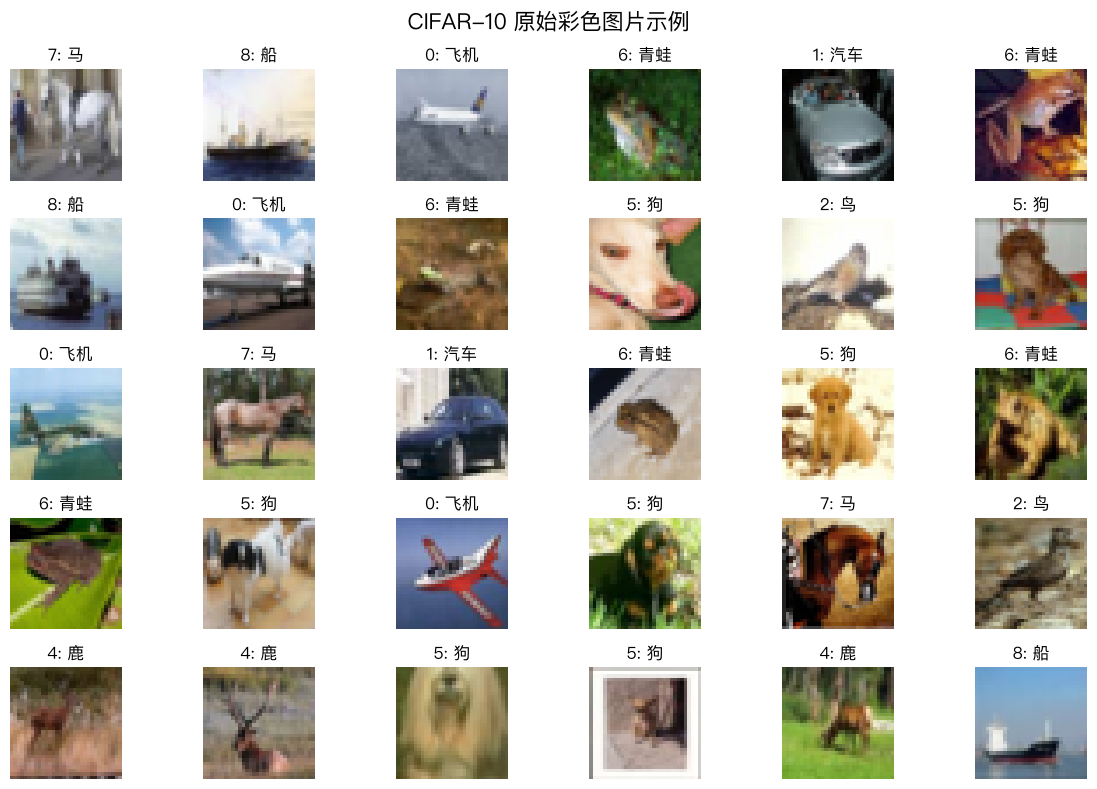

In [6]:
# ============================================================
# 第 2 步：展示一批 CIFAR-10 原始图片
# ============================================================

sample_indices = np.random.choice(len(x_train_full), size=30, replace=False)

plt.figure(figsize=(12, 8))
for plot_position, image_index in enumerate(sample_indices, start=1):
    image = x_train_full[image_index]
    label = y_train_full[image_index]

    plt.subplot(5, 6, plot_position)
    plt.imshow(image)
    plt.title(f"{label}: {class_names_cn[label]}")
    plt.axis("off")

plt.suptitle("CIFAR-10 原始彩色图片示例", fontsize=16)
plt.tight_layout()
plt.show()

# 第 3 步：理解 RGB 三通道

灰度图通常只有一个通道。  
彩色图通常有三个通道：

```text
R：Red，红色通道
G：Green，绿色通道
B：Blue，蓝色通道
```

所以 CIFAR-10 单张图片形状是：

```text
32 × 32 × 3
```

含义是：

```text
高度 32，宽度 32，颜色通道 3
```

示例图片形状： (32, 32, 3)
标签编号： 6
中文类别： 青蛙
红色通道形状： (32, 32)
绿色通道形状： (32, 32)
蓝色通道形状： (32, 32)


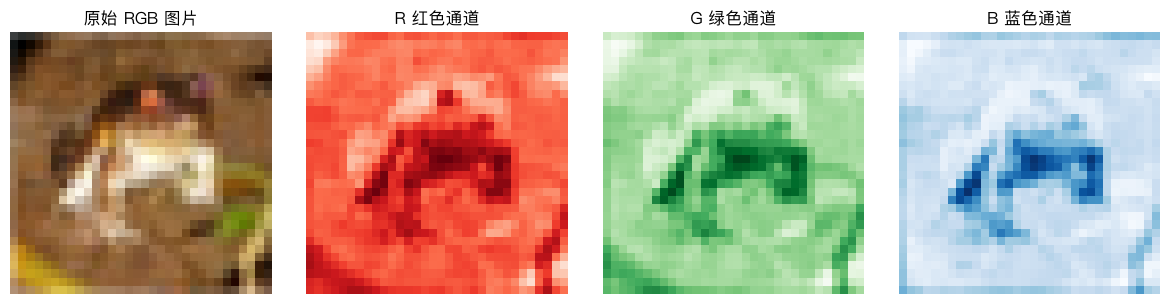

In [7]:
# ============================================================
# 第 3 步：拆开观察 RGB 三个颜色通道
# ============================================================

example_index = 0
example_image = x_train_full[example_index]
example_label = y_train_full[example_index]

red_channel = example_image[:, :, 0]
green_channel = example_image[:, :, 1]
blue_channel = example_image[:, :, 2]

print("示例图片形状：", example_image.shape)
print("标签编号：", example_label)
print("中文类别：", class_names_cn[example_label])
print("红色通道形状：", red_channel.shape)
print("绿色通道形状：", green_channel.shape)
print("蓝色通道形状：", blue_channel.shape)

plt.figure(figsize=(12, 3))

plt.subplot(1, 4, 1)
plt.imshow(example_image)
plt.title("原始 RGB 图片")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(red_channel, cmap="Reds")
plt.title("R 红色通道")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(green_channel, cmap="Greens")
plt.title("G 绿色通道")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(blue_channel, cmap="Blues")
plt.title("B 蓝色通道")
plt.axis("off")

plt.tight_layout()
plt.show()

# 第 4 步：观察标签分布

CIFAR-10 每个类别的图片数量比较均衡。

均衡的数据集更适合课堂演示，因为模型不容易因为某一类样本特别多而偏向该类别。

标签 0（飞机）：5000 张
标签 1（汽车）：5000 张
标签 2（鸟）：5000 张
标签 3（猫）：5000 张
标签 4（鹿）：5000 张
标签 5（狗）：5000 张
标签 6（青蛙）：5000 张
标签 7（马）：5000 张
标签 8（船）：5000 张
标签 9（卡车）：5000 张


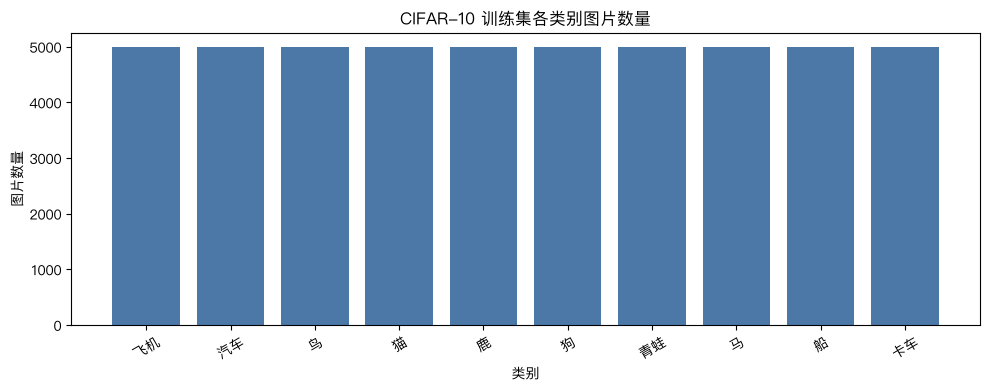

In [8]:
# ============================================================
# 第 4 步：观察训练集标签分布
# ============================================================

label_counts = np.bincount(y_train_full, minlength=10)

for label_id, count in enumerate(label_counts):
    print(f"标签 {label_id}（{class_names_cn[label_id]}）：{count} 张")

plt.figure(figsize=(10, 4))
plt.bar(class_names_cn, label_counts, color="#4C78A8")
plt.title("CIFAR-10 训练集各类别图片数量")
plt.xlabel("类别")
plt.ylabel("图片数量")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 第 5 步：数据归一化

CIFAR-10 原始像素值范围也是：

```text
0 到 255
```

训练神经网络时，通常把它缩放到：

```text
0 到 1
```

这样可以让模型训练更稳定。

In [9]:
# ============================================================
# 第 5 步：数据归一化
# ============================================================

x_train_full_normalized = x_train_full.astype("float32") / 255.0
x_test_normalized = x_test.astype("float32") / 255.0

print("归一化前像素范围：", x_train_full.min(), "到", x_train_full.max())
print("归一化后像素范围：", x_train_full_normalized.min(), "到", x_train_full_normalized.max())
print("归一化后训练图片形状：", x_train_full_normalized.shape)
print("归一化后测试图片形状：", x_test_normalized.shape)

归一化前像素范围： 0 到 255
归一化后像素范围： 0.0 到 1.0
归一化后训练图片形状： (50000, 32, 32, 3)
归一化后测试图片形状： (10000, 32, 32, 3)


# 第 6 步：拆分训练集和验证集

从训练集中分出一部分作为验证集，用来观察训练过程中模型对新图片的表现。

最终有三部分：

| 数据集 | 作用 |
|---|---|
| 训练集 | 用来调整模型参数 |
| 验证集 | 训练过程中观察模型表现 |
| 测试集 | 训练结束后进行最终评估 |

In [10]:
# ============================================================
# 第 6 步：拆分训练集和验证集
# ============================================================

indices = np.random.permutation(len(x_train_full_normalized))
validation_size = 5000
validation_indices = indices[:validation_size]
train_indices = indices[validation_size:]

x_val = x_train_full_normalized[validation_indices]
y_val = y_train_full[validation_indices]
x_train = x_train_full_normalized[train_indices]
y_train = y_train_full[train_indices]

print("训练集图片形状：", x_train.shape)
print("训练集标签形状：", y_train.shape)
print("验证集图片形状：", x_val.shape)
print("验证集标签形状：", y_val.shape)
print("测试集图片形状：", x_test_normalized.shape)
print("测试集标签形状：", y_test.shape)

训练集图片形状： (45000, 32, 32, 3)
训练集标签形状： (45000,)
验证集图片形状： (5000, 32, 32, 3)
验证集标签形状： (5000,)
测试集图片形状： (10000, 32, 32, 3)
测试集标签形状： (10000,)


# 第 7 步：理解数据增强

真实图片经常会发生变化，例如：

- 左右方向不同
- 角度略有旋转
- 物体大小略有变化
- 位置略有偏移

数据增强会在训练时随机制造一些轻微变化，让模型不要只记住训练图片的固定样子。

本案例使用三种简单增强：

```text
随机左右翻转
轻微旋转
轻微缩放
```

数据增强只在训练时生效，评估和预测时不会随机改变图片。

I0000 00:00:1782215193.945277 18092097 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1782215193.945529 18092097 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


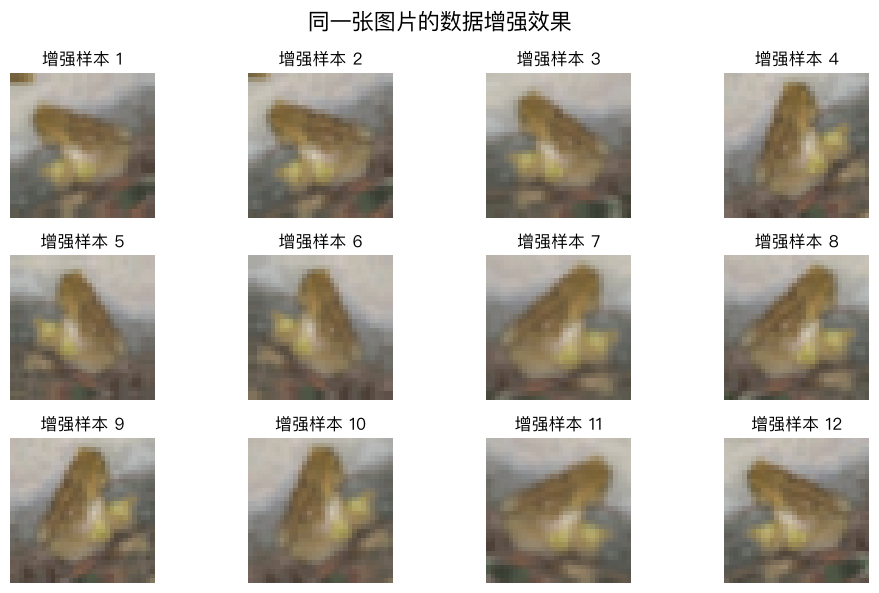

In [11]:
# ============================================================
# 第 7 步：创建数据增强层
# ============================================================

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", name="random_horizontal_flip"),
    layers.RandomRotation(0.08, name="random_small_rotation"),
    layers.RandomZoom(0.10, name="random_small_zoom"),
], name="data_augmentation")

# 展示同一张图片经过数据增强后的不同样子。
image_for_augmentation = x_train[:1]

plt.figure(figsize=(10, 6))
for i in range(12):
    augmented_image = data_augmentation(image_for_augmentation, training=True)[0].numpy()
    augmented_image = np.clip(augmented_image, 0, 1)

    plt.subplot(3, 4, i + 1)
    plt.imshow(augmented_image)
    plt.title(f"增强样本 {i + 1}")
    plt.axis("off")

plt.suptitle("同一张图片的数据增强效果", fontsize=16)
plt.tight_layout()
plt.show()

# 第 8 步：构建 CIFAR-10 CNN 模型

CIFAR-10 比 Fashion-MNIST 更难，因此模型会稍微更深一些。

本模型包含：

- `Conv2D`：提取局部图像特征
- `BatchNormalization`：让训练更稳定
- `MaxPooling2D`：缩小特征图
- `Dropout`：减少过拟合
- `Dense`：根据提取到的特征进行分类

模型结构大致如下：

```text
输入：32×32×3 彩色图片
        ↓
数据增强
        ↓
卷积组 1：32 个卷积核
        ↓
池化 + Dropout
        ↓
卷积组 2：64 个卷积核
        ↓
池化 + Dropout
        ↓
卷积组 3：128 个卷积核
        ↓
池化 + Dropout
        ↓
Flatten + Dense
        ↓
Softmax 输出 10 个类别概率
```

In [12]:
# ============================================================
# 第 8 步：构建 CIFAR-10 CNN 模型
# ============================================================

model = keras.Sequential([
    layers.Input(shape=(32, 32, 3), name="input_32x32_rgb_image"),

    # 数据增强层只在训练时随机改变图片。
    data_augmentation,

    # 第一组卷积：学习简单边缘、颜色块、局部纹理。
    layers.Conv2D(32, (3, 3), padding="same", use_bias=False, name="conv_1_32_filters"),
    layers.BatchNormalization(name="bn_1"),
    layers.Activation("relu", name="relu_1"),
    layers.Conv2D(32, (3, 3), padding="same", use_bias=False, name="conv_2_32_filters"),
    layers.BatchNormalization(name="bn_2"),
    layers.Activation("relu", name="relu_2"),
    layers.MaxPooling2D((2, 2), name="pool_1_2x2"),
    layers.Dropout(0.25, name="dropout_25_percent_1"),

    # 第二组卷积：学习更复杂的局部组合特征。
    layers.Conv2D(64, (3, 3), padding="same", use_bias=False, name="conv_3_64_filters"),
    layers.BatchNormalization(name="bn_3"),
    layers.Activation("relu", name="relu_3"),
    layers.Conv2D(64, (3, 3), padding="same", use_bias=False, name="conv_4_64_filters"),
    layers.BatchNormalization(name="bn_4"),
    layers.Activation("relu", name="relu_4"),
    layers.MaxPooling2D((2, 2), name="pool_2_2x2"),
    layers.Dropout(0.30, name="dropout_30_percent_2"),

    # 第三组卷积：学习更抽象的图像局部结构。
    layers.Conv2D(128, (3, 3), padding="same", use_bias=False, name="conv_5_128_filters"),
    layers.BatchNormalization(name="bn_5"),
    layers.Activation("relu", name="relu_5"),
    layers.Conv2D(128, (3, 3), padding="same", use_bias=False, name="conv_6_128_filters"),
    layers.BatchNormalization(name="bn_6"),
    layers.Activation("relu", name="relu_6"),
    layers.MaxPooling2D((2, 2), name="pool_3_2x2"),
    layers.Dropout(0.35, name="dropout_35_percent_3"),

    # 分类部分：把特征图拉平成向量，再进行分类。
    layers.Flatten(name="flatten_feature_maps"),
    layers.Dense(256, activation="relu", name="dense_256_relu"),
    layers.Dropout(0.50, name="dropout_50_percent"),
    # 输出层保持 float32，有助于混合精度训练时的数值稳定。
    layers.Dense(10, activation="softmax", dtype="float32", name="output_10_softmax"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1_32_filters (Conv2D)      │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2_32_filters (Conv2D)      │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1_2x2 (MaxPooling2D)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25_percent_1 (Dropout)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3_64_filters (Conv2D)      │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_4_64_filters (Conv2D)      │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_4 (Activation)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2_2x2 (MaxPooling2D)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30_percent_2 (Dropout)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_5_128_filters (Conv2D)     │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_5 (BatchNormalization)       │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_5 (Activation)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_6_128_filters (Conv2D)     │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_6 (BatchNormalization)       │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_6 (Activation)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3_2x2 (MaxPooling2D)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35_percent_3 (Dropout)  │ (None, 4, 4, 128)      │             

 Total params: 815,466 (3.11 MB)

 Trainable params: 814,570 (3.11 MB)

 Non-trainable params: 896 (3.50 KB)

# 第 9 步：观察 CNN 中数据形状的变化

从 `model.summary()` 可以看到每一层输出形状。

CIFAR-10 输入是：

```text
32×32×3
```

经过多次卷积和池化后，空间尺寸逐渐缩小，通道数逐渐增加。

这表示模型从“原始像素”逐步转向“更抽象的图像特征”。

In [13]:
# ============================================================
# 第 9 步：手动观察关键形状
# ============================================================

print("输入形状：", (32, 32, 3))
print("第一组池化后大约形状：", (16, 16, 32))
print("第二组池化后大约形状：", (8, 8, 64))
print("第三组池化后大约形状：", (4, 4, 128))
print("Flatten 后特征数量：", 4 * 4 * 128)
print("模型总参数数量：", model.count_params())

输入形状： (32, 32, 3)
第一组池化后大约形状： (16, 16, 32)
第二组池化后大约形状： (8, 8, 64)
第三组池化后大约形状： (4, 4, 128)
Flatten 后特征数量： 2048
模型总参数数量： 815466


# 第 10 步：训练 CNN 模型

CIFAR-10 比 Fashion-MNIST 更难。为了获得更稳定的效果，本案例默认训练 25 轮。

如果只是快速演示流程，可以把 `EPOCHS` 改小。  
如果希望准确率更高，可以继续增加训练轮数。

In [14]:
# ============================================================
# 第 10 步：训练 CNN 模型
# ============================================================

EPOCHS = 25
BATCH_SIZE = 128

history = model.fit(
    x_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=2,
)

Epoch 1/25


KeyboardInterrupt: 

# 第 11 步：可视化卷积特征图

卷积层会输出多张特征图。  
每张特征图表示某个卷积核在不同位置检测到的特征强度。

下面观察第一层卷积输出的部分特征图。

In [ ]:
# ============================================================
# 第 11 步：可视化第一层卷积特征图
# ============================================================

feature_image_index = 0
feature_image = x_test_normalized[feature_image_index:feature_image_index + 1]
feature_label = y_test[feature_image_index]

feature_model = keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer("conv_1_32_filters").output,
)

conv_features = feature_model.predict(feature_image, verbose=0)

print("原始图片形状：", feature_image.shape)
print("第一层卷积特征图形状：", conv_features.shape)

plt.figure(figsize=(4, 4))
plt.imshow(feature_image[0])
plt.title(f"原始图片：{class_names_cn[feature_label]}")
plt.axis("off")
plt.show()

num_features_to_show = 12
plt.figure(figsize=(12, 6))
for i in range(num_features_to_show):
    plt.subplot(3, 4, i + 1)
    plt.imshow(conv_features[0, :, :, i], cmap="viridis")
    plt.title(f"卷积特征 {i}")
    plt.axis("off")

plt.suptitle("第一层卷积后的部分特征图", fontsize=16)
plt.tight_layout()
plt.show()

# 第 12 步：绘制训练过程曲线

训练结束后，重点观察：

- 训练 loss 和验证 loss
- 训练 accuracy 和验证 accuracy

如果验证准确率明显低于训练准确率，说明模型可能有过拟合。  
数据增强和 Dropout 都是常见的缓解过拟合方法。

In [ ]:
# ============================================================
# 第 12 步：绘制 loss 和 accuracy 曲线
# ============================================================

history_dict = history.history
epoch_numbers = range(1, len(history_dict["loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epoch_numbers, history_dict["loss"], marker="o", label="训练 loss")
plt.plot(epoch_numbers, history_dict["val_loss"], marker="o", label="验证 loss")
plt.title("训练过程中的 loss 变化")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epoch_numbers, history_dict["accuracy"], marker="o", label="训练 accuracy")
plt.plot(epoch_numbers, history_dict["val_accuracy"], marker="o", label="验证 accuracy")
plt.title("训练过程中的 accuracy 变化")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 第 13 步：在测试集上评估模型

测试集没有参与训练，也没有参与训练过程中的验证。

测试集准确率可以反映模型面对新图片时的整体表现。

In [ ]:
# ============================================================
# 第 13 步：测试集评估
# ============================================================

test_loss, test_accuracy = model.evaluate(x_test_normalized, y_test, verbose=0)

print("测试集 loss：", test_loss)
print("测试集 accuracy：", test_accuracy)
print(f"测试集准确率约为：{test_accuracy * 100:.2f}%")

# 第 14 步：观察单张图片的预测过程

模型最后输出 10 个概率。  
概率最大的类别，就是模型最终预测的类别。

In [ ]:
# ============================================================
# 第 14 步：单张图片预测
# ============================================================

test_index = 0
single_image = x_test_normalized[test_index]
single_label = y_test[test_index]
single_image_batch = np.expand_dims(single_image, axis=0)

probabilities = model.predict(single_image_batch, verbose=0)[0]
predicted_label = np.argmax(probabilities)

print("真实标签编号：", single_label)
print("真实类别：", class_names_cn[single_label])
print("预测标签编号：", predicted_label)
print("预测类别：", class_names_cn[predicted_label])
print("预测是否正确：", predicted_label == single_label)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(single_image)
plt.title(f"真实：{class_names_cn[single_label]} / 预测：{class_names_cn[predicted_label]}")
plt.axis("off")

plt.subplot(1, 2, 2)
bar_colors = ["#F58518" if i == predicted_label else "#4C78A8" for i in range(10)]
plt.bar(class_names_cn, probabilities, color=bar_colors)
plt.title("10 个类别的 Softmax 概率")
plt.ylabel("概率")
plt.ylim(0, 1)
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

for label_id, probability in enumerate(probabilities):
    print(f"{label_id} {class_names_cn[label_id]}：{probability:.4f}")

# 第 15 步：批量展示预测结果

下面展示测试集中前 30 张图片的预测结果。

标题含义：

```text
真：真实类别
预：预测类别
```

颜色含义：

- 绿色：预测正确
- 红色：预测错误

In [ ]:
# ============================================================
# 第 15 步：批量展示测试集预测结果
# ============================================================

num_show = 30
predictions = model.predict(x_test_normalized[:num_show], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(14, 8))
for i in range(num_show):
    true_label = y_test[i]
    predicted_label = predicted_labels[i]
    correct = true_label == predicted_label
    title_color = "green" if correct else "red"

    plt.subplot(5, 6, i + 1)
    plt.imshow(x_test_normalized[i])
    plt.title(
        f"真:{class_names_cn[true_label]}\n预:{class_names_cn[predicted_label]}",
        color=title_color,
        fontsize=9,
    )
    plt.axis("off")

plt.suptitle("CIFAR-10 测试集前 30 张图片预测结果", fontsize=16)
plt.tight_layout()
plt.show()

# 第 16 步：混淆矩阵

混淆矩阵可以分析模型容易混淆哪些类别。

CIFAR-10 中常见的混淆可能包括：

- 猫和狗
- 汽车和卡车
- 鸟和飞机
- 鹿、马、狗等动物类别

In [ ]:
# ============================================================
# 第 16 步：计算并展示混淆矩阵
# ============================================================

all_predictions = model.predict(x_test_normalized, verbose=0)
all_predicted_labels = np.argmax(all_predictions, axis=1)

confusion_matrix = tf.math.confusion_matrix(
    labels=y_test,
    predictions=all_predicted_labels,
    num_classes=10,
).numpy()

print("混淆矩阵：")
print(confusion_matrix)

plt.figure(figsize=(9, 8))
plt.imshow(confusion_matrix, cmap="Blues")
plt.title("CIFAR-10 CNN 混淆矩阵")
plt.xlabel("预测类别")
plt.ylabel("真实类别")
plt.xticks(range(10), class_names_cn, rotation=45)
plt.yticks(range(10), class_names_cn)
plt.colorbar()

for row in range(10):
    for col in range(10):
        value = confusion_matrix[row, col]
        text_color = "white" if value > confusion_matrix.max() * 0.5 else "black"
        plt.text(col, row, str(value), ha="center", va="center", color=text_color, fontsize=9)

plt.tight_layout()
plt.show()

# 第 17 步：找出最容易混淆的类别

混淆矩阵中：

- 对角线表示预测正确的数量
- 非对角线表示预测错误的数量

下面找出非对角线中数量最多的几个错误组合。

In [ ]:
# ============================================================
# 第 17 步：分析最常见的错误组合
# ============================================================

cm_without_diagonal = confusion_matrix.copy()
np.fill_diagonal(cm_without_diagonal, 0)

flat_indices = np.argsort(cm_without_diagonal.ravel())[::-1]
top_k = 8
shown = 0

print(f"最常见的 {top_k} 类错误：")
for flat_index in flat_indices:
    true_label, predicted_label = np.unravel_index(flat_index, cm_without_diagonal.shape)
    count = cm_without_diagonal[true_label, predicted_label]

    if count == 0:
        break

    print(
        f"真实是 {class_names_cn[true_label]}，"
        f"被预测成 {class_names_cn[predicted_label]}：{count} 张"
    )

    shown += 1
    if shown >= top_k:
        break

# 第 18 步：展示预测错误的图片

CIFAR-10 图片很小，很多错误可以从图片本身看出原因。

常见原因包括：

1. 图片分辨率低，细节不清楚。
2. 物体只占画面一小部分。
3. 背景和主体颜色接近。
4. 类别本身相似，例如猫和狗、汽车和卡车。

In [ ]:
# ============================================================
# 第 18 步：展示模型预测错误的图片
# ============================================================

wrong_indices = np.where(all_predicted_labels != y_test)[0]

print(f"测试集中一共有 {len(wrong_indices)} 张预测错误。")
print(f"测试集总数：{len(y_test)}")
print(f"错误率约为：{len(wrong_indices) / len(y_test) * 100:.2f}%")

num_wrong_show = min(24, len(wrong_indices))
wrong_show_indices = wrong_indices[:num_wrong_show]

plt.figure(figsize=(14, 8))
for plot_position, image_index in enumerate(wrong_show_indices, start=1):
    true_label = y_test[image_index]
    predicted_label = all_predicted_labels[image_index]
    confidence = all_predictions[image_index, predicted_label]

    plt.subplot(4, 6, plot_position)
    plt.imshow(x_test_normalized[image_index])
    plt.title(
        f"真:{class_names_cn[true_label]}\n预:{class_names_cn[predicted_label]}\n置信:{confidence:.2f}",
        color="red",
        fontsize=9,
    )
    plt.axis("off")

plt.suptitle("预测错误的图片示例", fontsize=16)
plt.tight_layout()
plt.show()

# 第 19 步：保存模型

训练完成后，可以把模型保存下来。之后如果继续使用这个模型，不需要重新训练，直接加载即可。

Keras 推荐保存为 `.keras` 格式。

In [ ]:
# ============================================================
# 第 19 步：保存模型
# ============================================================

model_save_path = "cifar10_cnn_model.keras"
model.save(model_save_path)

print("模型已保存到：", model_save_path)

# 第 20 步：重新加载模型并验证

保存模型之后，可以用 `keras.models.load_model()` 重新加载。

这一步用于确认保存文件可以正常使用。

In [ ]:
# ============================================================
# 第 20 步：重新加载模型并验证
# ============================================================

loaded_model = keras.models.load_model(model_save_path)
loaded_loss, loaded_accuracy = loaded_model.evaluate(x_test_normalized, y_test, verbose=0)

print("重新加载后的测试集 loss：", loaded_loss)
print("重新加载后的测试集 accuracy：", loaded_accuracy)

loaded_prediction = loaded_model.predict(np.expand_dims(x_test_normalized[0], axis=0), verbose=0)[0]
loaded_predicted_label = np.argmax(loaded_prediction)

print("第 0 张测试图片真实类别：", class_names_cn[y_test[0]])
print("重新加载模型后的预测类别：", class_names_cn[loaded_predicted_label])

# 第 21 步：总结

通过这个案例，已经完成了一个完整的 CIFAR-10 彩色图片 CNN 分类任务。

核心流程如下：

1. CIFAR-10 是彩色图片数据集，每张图片是 `32×32×3`。
2. `3` 表示 RGB 三个颜色通道。
3. 真实彩色图片比灰度服饰图片更复杂。
4. 数据增强可以让模型看到更多图片变化，提升泛化能力。
5. 卷积层提取局部图像特征。
6. BatchNormalization 可以让训练更稳定。
7. 池化层缩小特征图，保留重要局部特征。
8. Dropout 可以减少过拟合。
9. Softmax 输出 10 个类别的概率。
10. 混淆矩阵和错误图片可以帮助分析模型容易错在哪里。

最核心的一句话：

> CIFAR-10 展示了 CNN 在真实彩色图片分类中的作用：模型不是直接记住整张图片，而是从局部颜色、纹理、边缘和形状中逐步提取特征。